<a href="https://colab.research.google.com/github/RECTY45/232052_sistempemesanantiketpesawat/blob/main/consine_similarity_retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install sastrawi

In [62]:
document = {
    "d1" : "Nama saya Fery Fadul Rahman, saya memiliki hobi bermain gitar serta senang mempelajari berbagai hal baru terutama di bidang pemrograman🤗.",
    "d2" : "Makassar adalah kota terbesar di wilayah Sulawesi Selatan yang kini terus berkembang pesat dan direncanakan menjadi salah satu kota dunia.",
    "d3" : "Di aula kampus Unitama, para dosen sedang mengadakan rapat koordinasi untuk memperkuat kerja sama antar staf pengajar sekaligus meningkatkan mutu pembelajaran.",
    "d4" : "Di kampus Unitama Makassar, Pasnur dikenal sebagai salah satu dosen yang cukup aktif dalam berbagai kegiatan akademik.",
    "d5" : "Menurut saya, mata kuliah Sistem Temu Kembali Informasi sangat menarik untuk dipelajari, dan saya berharap bisa mendapatkan banyak pengetahuan karena saya memiliki ketertarikan pada STKI (Sistem Temu Kembali Informasi).",
    "d6" : "Seperti apa hubungan keakraban antara dosen dan mahasiswa di lingkungan kampus Unitama dalam kegiatan sehari-hari?",
    "q"  : "Mahasiswa Unitama Makassar"
}

In [63]:
import pandas as pd

df = pd.DataFrame(list(document.items()), columns=["document_id", "document_contents"])
df

,document_id,document_contents
0,d1,"Nama saya Fery Fadul Rahman, saya memiliki hob..."
1,d2,Makassar adalah kota terbesar di wilayah Sulaw...
2,d3,"Di aula kampus Unitama, para dosen sedang meng..."
3,d4,"Di kampus Unitama Makassar, Pasnur dikenal seb..."
4,d5,"Menurut saya, mata kuliah Sistem Temu Kembali ..."
5,d6,Seperti apa hubungan keakraban antara dosen da...
6,q,Mahasiswa Unitama Makassar


In [36]:
def case_folding(text):
  return text.lower()

In [64]:
df["contents_casefolding"] = df["document_contents"].apply(case_folding)
df

,document_id,document_contents,contents_casefolding
0,d1,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob..."
1,d2,Makassar adalah kota terbesar di wilayah Sulaw...,makassar adalah kota terbesar di wilayah sulaw...
2,d3,"Di aula kampus Unitama, para dosen sedang meng...","di aula kampus unitama, para dosen sedang meng..."
3,d4,"Di kampus Unitama Makassar, Pasnur dikenal seb...","di kampus unitama makassar, pasnur dikenal seb..."
4,d5,"Menurut saya, mata kuliah Sistem Temu Kembali ...","menurut saya, mata kuliah sistem temu kembali ..."
5,d6,Seperti apa hubungan keakraban antara dosen da...,seperti apa hubungan keakraban antara dosen da...
6,q,Mahasiswa Unitama Makassar,mahasiswa unitama makassar


In [65]:
import re

import re

def filtering(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [66]:
df['contents_filtering'] = df["contents_casefolding"].apply(filtering)
df

,document_id,document_contents,contents_casefolding,contents_filtering
0,d1,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob...",nama saya fery fadul rahman saya memiliki hobi...
1,d2,Makassar adalah kota terbesar di wilayah Sulaw...,makassar adalah kota terbesar di wilayah sulaw...,makassar adalah kota terbesar di wilayah sulaw...
2,d3,"Di aula kampus Unitama, para dosen sedang meng...","di aula kampus unitama, para dosen sedang meng...",di aula kampus unitama para dosen sedang menga...
3,d4,"Di kampus Unitama Makassar, Pasnur dikenal seb...","di kampus unitama makassar, pasnur dikenal seb...",di kampus unitama makassar pasnur dikenal seba...
4,d5,"Menurut saya, mata kuliah Sistem Temu Kembali ...","menurut saya, mata kuliah sistem temu kembali ...",menurut saya mata kuliah sistem temu kembali i...
5,d6,Seperti apa hubungan keakraban antara dosen da...,seperti apa hubungan keakraban antara dosen da...,seperti apa hubungan keakraban antara dosen da...
6,q,Mahasiswa Unitama Makassar,mahasiswa unitama makassar,mahasiswa unitama makassar


In [67]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def remove_stopword(text) :
  return stopword_remover.remove(text)

In [68]:
df["contents_stopword"] = df["contents_filtering"].apply(remove_stopword)
df

,document_id,document_contents,contents_casefolding,contents_filtering,contents_stopword
0,d1,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob...",nama saya fery fadul rahman saya memiliki hobi...,nama fery fadul rahman memiliki hobi bermain g...
1,d2,Makassar adalah kota terbesar di wilayah Sulaw...,makassar adalah kota terbesar di wilayah sulaw...,makassar adalah kota terbesar di wilayah sulaw...,makassar kota terbesar wilayah sulawesi selata...
2,d3,"Di aula kampus Unitama, para dosen sedang meng...","di aula kampus unitama, para dosen sedang meng...",di aula kampus unitama para dosen sedang menga...,aula kampus unitama dosen sedang mengadakan ra...
3,d4,"Di kampus Unitama Makassar, Pasnur dikenal seb...","di kampus unitama makassar, pasnur dikenal seb...",di kampus unitama makassar pasnur dikenal seba...,kampus unitama makassar pasnur dikenal salah s...
4,d5,"Menurut saya, mata kuliah Sistem Temu Kembali ...","menurut saya, mata kuliah sistem temu kembali ...",menurut saya mata kuliah sistem temu kembali i...,saya mata kuliah sistem temu informasi sangat ...
5,d6,Seperti apa hubungan keakraban antara dosen da...,seperti apa hubungan keakraban antara dosen da...,seperti apa hubungan keakraban antara dosen da...,apa hubungan keakraban dosen mahasiswa lingkun...
6,q,Mahasiswa Unitama Makassar,mahasiswa unitama makassar,mahasiswa unitama makassar,mahasiswa unitama makassar


In [48]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def stemming(text):
  return stemmer.stem(text)

In [69]:
df["contents_stemming"] = df["contents_stopword"].apply(stemming)
df

,document_id,document_contents,contents_casefolding,contents_filtering,contents_stopword,contents_stemming
0,d1,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob...",nama saya fery fadul rahman saya memiliki hobi...,nama fery fadul rahman memiliki hobi bermain g...,nama fery fadul rahman milik hobi main gitar s...
1,d2,Makassar adalah kota terbesar di wilayah Sulaw...,makassar adalah kota terbesar di wilayah sulaw...,makassar adalah kota terbesar di wilayah sulaw...,makassar kota terbesar wilayah sulawesi selata...,makassar kota besar wilayah sulawesi selatan k...
2,d3,"Di aula kampus Unitama, para dosen sedang meng...","di aula kampus unitama, para dosen sedang meng...",di aula kampus unitama para dosen sedang menga...,aula kampus unitama dosen sedang mengadakan ra...,aula kampus unitama dosen sedang ada rapat koo...
3,d4,"Di kampus Unitama Makassar, Pasnur dikenal seb...","di kampus unitama makassar, pasnur dikenal seb...",di kampus unitama makassar pasnur dikenal seba...,kampus unitama makassar pasnur dikenal salah s...,kampus unitama makassar pasnur kenal salah sat...
4,d5,"Menurut saya, mata kuliah Sistem Temu Kembali ...","menurut saya, mata kuliah sistem temu kembali ...",menurut saya mata kuliah sistem temu kembali i...,saya mata kuliah sistem temu informasi sangat ...,saya mata kuliah sistem temu informasi sangat ...
5,d6,Seperti apa hubungan keakraban antara dosen da...,seperti apa hubungan keakraban antara dosen da...,seperti apa hubungan keakraban antara dosen da...,apa hubungan keakraban dosen mahasiswa lingkun...,apa hubung akrab dosen mahasiswa lingkung kamp...
6,q,Mahasiswa Unitama Makassar,mahasiswa unitama makassar,mahasiswa unitama makassar,mahasiswa unitama makassar,mahasiswa unitama makassar


In [70]:
df_clean = df[["document_id", "contents_stemming"]].copy()
df_clean.columns = ["document_id", "document_contents"]
df_clean

,document_id,document_contents
0,d1,nama fery fadul rahman milik hobi main gitar s...
1,d2,makassar kota besar wilayah sulawesi selatan k...
2,d3,aula kampus unitama dosen sedang ada rapat koo...
3,d4,kampus unitama makassar pasnur kenal salah sat...
4,d5,saya mata kuliah sistem temu informasi sangat ...
5,d6,apa hubung akrab dosen mahasiswa lingkung kamp...
6,q,mahasiswa unitama makassar


In [71]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_clean["document_contents"])

tf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df_clean["document_id"]
)

tf_transpose = tf_df.T

tf_transpose.reset_index(inplace=True)
tf_transpose.rename(columns={"index": "Term/Kata"}, inplace=True)

tf_transpose

document_id,Term/Kata,d1,d2,d3,d4,d5,d6,q
0,ada,0,0,1,0,0,0,0
1,ajar,1,0,2,0,1,0,0
2,akademik,0,0,0,1,0,0,0
3,akrab,0,0,0,0,0,1,0
4,aktif,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...
67,terus,0,1,0,0,0,0,0
68,tingkat,0,0,1,0,0,0,0
69,unitama,0,0,1,1,0,1,1
70,utama,1,0,0,0,0,0,0


In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer(
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=False,
    norm=None
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean["document_contents"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df.insert(0, "document_id", df_clean["document_id"])

tfidf_df

,document_id,ada,ajar,akademik,akrab,aktif,antar,apa,aula,bagai,...,sulawesi,tahu,tari,tarik,temu,terus,tingkat,unitama,utama,wilayah
0,d1,0.000000,1.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.980829,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.386294,0.000000
1,d2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.386294,0.000000,0.000000,0.000000,0.000000,2.386294,0.000000,0.000000,0.000000,2.386294
2,d3,2.386294,3.386294,0.000000,0.000000,0.000000,2.386294,0.000000,2.386294,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.386294,1.470004,0.000000,0.000000
3,d4,0.000000,0.000000,2.386294,0.000000,2.386294,0.000000,0.000000,0.000000,1.980829,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470004,0.000000,0.000000
4,d5,0.000000,1.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2.386294,2.386294,2.386294,4.772589,0.000000,0.000000,0.000000,0.000000,0.000000
5,d6,0.000000,0.000000,0.000000,2.386294,0.000000,0.000000,2.386294,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470004,0.000000,0.000000
6,q,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470004,0.000000,0.000000


In [73]:
import numpy as np

query_vec = tfidf_df[tfidf_df["document_id"] == "q"].drop(columns=["document_id"]).values[0]

hasil = []

for i, row in tfidf_df.iterrows():
    if row["document_id"] == "q":
        continue

    doc_vec = row.drop("document_id").values

    dot = np.dot(query_vec, doc_vec)
    norm_q = np.linalg.norm(query_vec)
    norm_d = np.linalg.norm(doc_vec)

    sim = dot / (norm_q * norm_d)

    hasil.append((row["document_id"], sim))

sim_df = pd.DataFrame(hasil, columns=["document_id", "cosine_similarity"])
sim_df = sim_df.sort_values(by="cosine_similarity", ascending=False)

sim_df

,document_id,cosine_similarity
5,d6,0.259757
3,d4,0.226738
1,d2,0.097727
2,d3,0.074739
0,d1,0.000000
4,d5,0.000000


In [74]:
threshold = 0.2

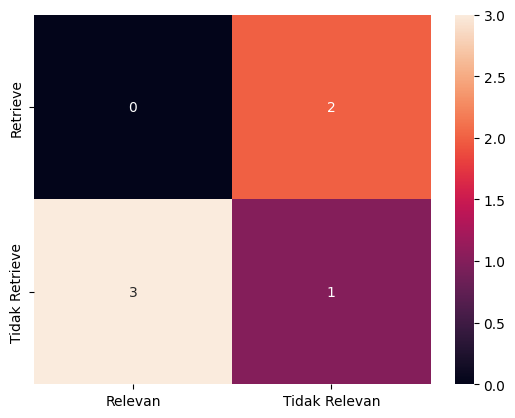

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

relevansi = {
    "d1":1, "d2":1, "d3":1,
    "d4":0, "d5":0, "d6":0
}

sim_df["prediksi"] = sim_df["cosine_similarity"].apply(lambda x: 1 if x >= threshold else 0)
sim_df["aktual"] = sim_df["document_id"].map(relevansi)

TP = len(sim_df[(sim_df.prediksi==1)&(sim_df.aktual==1)])
FP = len(sim_df[(sim_df.prediksi==1)&(sim_df.aktual==0)])
FN = len(sim_df[(sim_df.prediksi==0)&(sim_df.aktual==1)])
TN = len(sim_df[(sim_df.prediksi==0)&(sim_df.aktual==0)])

cm = [[TP, FP],[FN, TN]]

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Relevan","Tidak Relevan"],
            yticklabels=["Retrieve","Tidak Retrieve"])
plt.show()

In [76]:
precision = TP/(TP+FP)
recall = TP/(TP+FN)

if (precision + recall) == 0:
    f1 = 0.0
else:
    f1 = 2*(precision*recall)/(precision+recall)

accuracy = (TP+TN)/(TP+TN+FP+FN)

print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", accuracy)

TP: 0
FP: 2
FN: 3
TN: 1
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Accuracy: 0.16666666666666666
